In [3]:
import polars as pl
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [4]:
transaction_df = pl.read_csv("../data/raw/train_transaction.csv")
identity_df = pl.read_csv("../data/raw/train_identity.csv")

print(transaction_df.shape)
print(identity_df.shape)

(590540, 394)
(144233, 41)


In [6]:
df = transaction_df.join(
    identity_df,
    on="TransactionID",
    how="left"
)

print(df.shape)

(590540, 434)


In [7]:
df.head()

TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,…,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
i64,i64,i64,f64,str,i64,f64,f64,str,f64,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,str,str,str,str,str,f64,str,str,str,str,str,str,str,str
2987000,0,86400,68.5,"""W""",13926,null,150.0,"""discover""",142.0,"""credit""",315.0,87.0,19.0,null,null,null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,null,13.0,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987001,0,86401,29.0,"""W""",2755,404.0,150.0,"""mastercard""",102.0,"""credit""",325.0,87.0,null,null,"""gmail.com""",null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,null,null,0.0,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987002,0,86469,59.0,"""W""",4663,490.0,150.0,"""visa""",166.0,"""debit""",330.0,87.0,287.0,null,"""outlook.com""",null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,null,null,0.0,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987003,0,86499,50.0,"""W""",18132,567.0,150.0,"""mastercard""",117.0,"""debit""",476.0,87.0,null,null,"""yahoo.com""",null,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
2987004,0,86506,50.0,"""H""",4497,514.0,150.0,"""mastercard""",102.0,"""credit""",420.0,87.0,null,null,"""gmail.com""",null,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,null,null,null,null,null,…,null,null,null,null,null,null,null,100.0,"""NotFound""",null,-480.0,"""New""","""NotFound""",166.0,null,542.0,144.0,null,null,null,null,null,null,null,"""New""","""NotFound""","""Android 7.0""","""samsung browser 6.2""",32.0,"""2220x1080""","""match_status:2""","""T""","""F""","""T""","""T""","""mobile""","""SAMSUNG SM-G892A Build/NRD90M"""


In [8]:
df = transaction_df.join(
    identity_df,
    on="TransactionID",
    how="left"
)

print(df.shape)

(590540, 434)


In [9]:
fraud_counts = (
    df.group_by("isFraud")
    .len()
)

print(fraud_counts)

shape: (2, 2)
┌─────────┬────────┐
│ isFraud ┆ len    │
│ ---     ┆ ---    │
│ i64     ┆ u32    │
╞═════════╪════════╡
│ 1       ┆ 20663  │
│ 0       ┆ 569877 │
└─────────┴────────┘


In [10]:
df['isFraud'].value_counts(normalize=True)

isFraud,proportion
i64,f64
1,0.03499
0,0.96501


In [11]:
missing_df = (
    df.null_count()
    .transpose(include_header=True)
)

missing_df.columns = ["column", "missing_count"]

missing_df = missing_df.with_columns(
    (
        pl.col("missing_count") / len(df) * 100
    ).alias("missing_percentage")
)

missing_df = missing_df.sort(
    "missing_percentage",
    descending=True
)

missing_df.head(20)

column,missing_count,missing_percentage
str,u32,f64
"""id_24""",585793,99.196159
"""id_25""",585408,99.130965
"""id_07""",585385,99.12707
"""id_08""",585385,99.12707
"""id_21""",585381,99.126393
…,…,…
"""id_03""",524216,88.768923
"""id_04""",524216,88.768923
"""D6""",517353,87.606767


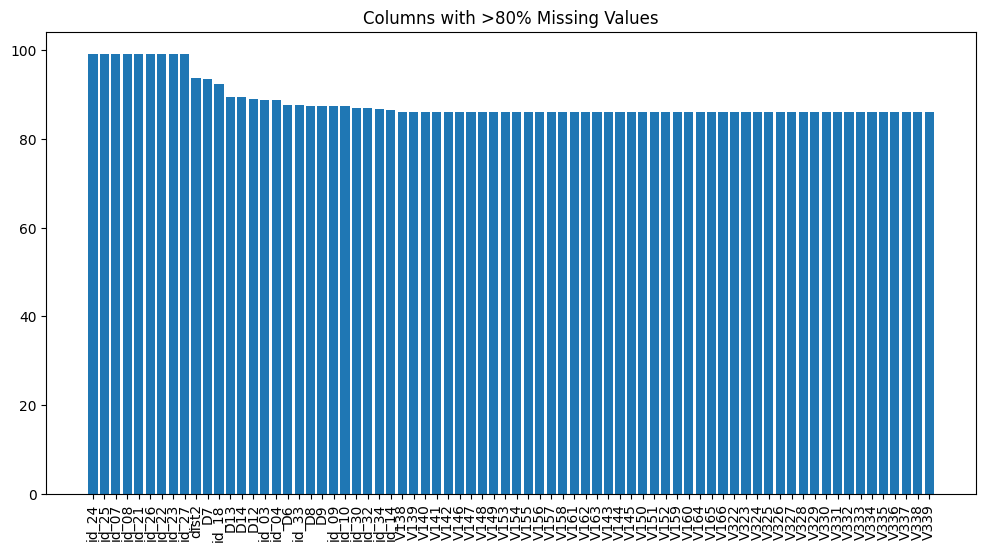

In [ ]:
missing_plot = missing_df.filter(
   
    THRESHOLD = 80
 
    pl.col("missing_percentage") > THRESHOLD
)

plt.figure(figsize=(12,6))

plt.bar(
    missing_plot["column"].to_list(),
    missing_plot["missing_percentage"].to_list()
)

plt.xticks(rotation=90)

plt.title("Columns with >80% Missing Values")

plt.show()

In [13]:
print(df.schema)

Schema([('TransactionID', Int64), ('isFraud', Int64), ('TransactionDT', Int64), ('TransactionAmt', Float64), ('ProductCD', String), ('card1', Int64), ('card2', Float64), ('card3', Float64), ('card4', String), ('card5', Float64), ('card6', String), ('addr1', Float64), ('addr2', Float64), ('dist1', Float64), ('dist2', Float64), ('P_emaildomain', String), ('R_emaildomain', String), ('C1', Float64), ('C2', Float64), ('C3', Float64), ('C4', Float64), ('C5', Float64), ('C6', Float64), ('C7', Float64), ('C8', Float64), ('C9', Float64), ('C10', Float64), ('C11', Float64), ('C12', Float64), ('C13', Float64), ('C14', Float64), ('D1', Float64), ('D2', Float64), ('D3', Float64), ('D4', Float64), ('D5', Float64), ('D6', Float64), ('D7', Float64), ('D8', Float64), ('D9', Float64), ('D10', Float64), ('D11', Float64), ('D12', Float64), ('D13', Float64), ('D14', Float64), ('D15', Float64), ('M1', String), ('M2', String), ('M3', String), ('M4', String), ('M5', String), ('M6', String), ('M7', String), ('

In [14]:
categorical_cols = [
    col for col, dtype in df.schema.items()
    if dtype == pl.String
]

print("Number of categorical columns:", len(categorical_cols))

categorical_cols[:20]

Number of categorical columns: 31


['ProductCD',
 'card4',
 'card6',
 'P_emaildomain',
 'R_emaildomain',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'id_12',
 'id_15',
 'id_16',
 'id_23',
 'id_27',
 'id_28']

In [15]:
numerical_cols = [
    col for col, dtype in df.schema.items()
    if dtype != pl.String
]

print("Number of numerical columns:", len(numerical_cols))

Number of numerical columns: 403


In [16]:
corr_df = (
    df.select(
        [
            pl.corr(col, "isFraud").alias(col)
            for col in numerical_cols
            if col != "isFraud"
        ]
    )
)

corr_pd = corr_df.to_pandas().T.reset_index()

corr_pd.columns = ["feature", "correlation"]

corr_pd["abs_corr"] = corr_pd["correlation"].abs()

corr_pd.sort_values(
    "abs_corr",
    ascending=False
).head(20)

,feature,correlation,abs_corr
296,V257,0.383060,0.383060
285,V246,0.366878,0.366878
283,V244,0.364129,0.364129
281,V242,0.360590,0.360590
240,V201,0.328005,0.328005
239,V200,0.318783,0.318783
228,V189,0.308219,0.308219
227,V188,0.303582,0.303582
297,V258,0.297151,0.297151
84,V45,0.281832,0.281832


In [17]:
print(df.estimated_size("mb"), "MB")

1863.62575340271 MB


In [18]:
df.write_parquet(
    "../data/processed/merged_data.parquet"
)